# Plotting training results

This notebook serves as a visualization tool for the training results of the **FlowerLLM** training results.
It reads the metric from the training curves directly from Wandb and collect them in `pandas` data frames ready to be analyzed and plotted.

In [81]:
# Imports
from matplotlib import pyplot as plt
import matplotlib.style as mplstyle
import matplotlib.patches as mpatches
import wandb
import pandas as pd
import seaborn as sns

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["font.weight"] = "bold"
# Colors and line styles
color_palette = sns.color_palette("colorblind")
line_styles = ["-", "--", ":", "-."]
# Bolded axis labels
plt.rcParams["axes.labelweight"] = "bold"
mplstyle.use("fast")

In [82]:
# Set the run_id to be retrieved
run_id_dict = {
    "fed-1B-short": [
        ("fed-1B-20240322_221900-fix-nesto", 8),
    ],
    "fed-1B-long": [
        ("fed-1B-20240314_232607", 8),
    ],
    "cen-1B": [
        ("centralised-1B-20240229_104204", 0),
    ],
    "fed-350M": [
        ("fed-350M-20240506_204125", 8),
        ("fed-350M-20240505_100605", 8),
    ],
    "cen-350M": [
        ("centralised-350M-20240305_191112", 0),
    ],
    "fed-160M": [],
    "cen-160M": [],
    "fed-125M": [
        ("fed-125M-20240502_203012-continue-3", 8),
        ("fed-125M-20240502_203012", 8),
    ],
    "cen-125M": [],
    "fed-75M": [("fed-75M-20240506_234900", 8)],
    "cen-75M": [("centralised-75M-20240508_212653", 0)],
}

In [83]:
# Server metrics columns
server_metrics_columns = [
    # Train-specific metrics
    "LanguageCrossEntropy",
    "LanguagePerplexity",
    # Val-specific metrics
    "ValLanguageCrossEntropy",
    "ValLanguagePerplexity",
    # Wandb internals
    "_runtime",
    "_step",
    "_timestamp",
    # Client-side bookkeeping
    "client/eval_init_time",
    "client/eval_metrics_collection_time",
    "client/eval_time",
    "client/eval_trainer_closing_time",
    "client/fit_get_parameters_time",
    "client/fit_init_time",
    "client/fit_metrics_collection_time",
    "client/fit_time",
    "client/fit_trainer_closing_time",
    # Client-side metrics
    "client/l2_norm_pseudo_gradient",
    "client_state_acc",
    "distributed_loss",
    # Node-side bookkeeping
    "node_eval_time_s",
    "node_training_time_s",
    # Server-side bookkeeping
    "server/evaluate_round_time",
    "server/evaluate_time",
    "server/first_check_nm_time",
    "server/fit_round_time",
    "server/round_time",
    "server/second_check_nm_time",
    # Server-side computed norms
    "server/l2_norm_fedavg_result",
    "server/l2_norm_model",
    "server/l2_norm_momentum_vector",
    "server/l2_norm_pseudo_gradient",
    # Step
    "step",
    # Worker-side bookkeeping
    "worker/partial_aggregation_time",
]

In [84]:
# Client metrics columns
client_metrics_columns = [
    # Wandb internals
    "_runtime",
    "_step",
    "_timestamp",
    # Activation norms
    "activations/l2_norm/full_model_input",
    "activations/l2_norm/full_model_output",
    # CID
    "client_id",
    # Momentum, gradient and model norms
    "l2_norm/grad/global",
    "l2_norm/moment/global",
    "l2_norm/param/global",
    "l2_norm/update/global",
    # Train loss
    "loss/train/total",
    # LR
    "lr-DecoupledAdamW/group0",
    # Memory metrics
    "memory/alloc_retries",
    "memory/current_active_mem",
    "memory/current_allocated_mem",
    "memory/current_inactive_mem",
    "memory/current_reserved_mem",
    "memory/peak_active_mem",
    "memory/peak_allocated_mem",
    "memory/peak_inactive_mem",
    "memory/peak_reserved_mem",
    "metrics/train/LanguageCrossEntropy",
    "metrics/train/LanguagePerplexity",
    # Step
    "step",
    # Throughput metrics
    "throughput/batches_per_sec",
    "throughput/device/batches_per_sec",
    "throughput/device/flops_per_sec",
    "throughput/device/mfu",
    "throughput/device/samples_per_sec",
    "throughput/device/tokens_per_sec",
    "throughput/flops_per_sec",
    "throughput/samples_per_sec",
    "throughput/tokens_per_sec",
    # Time metrics
    "time/batch",
    "time/batch_in_epoch",
    "time/epoch",
    "time/remaining_estimate",
    "time/sample",
    "time/sample_in_epoch",
    "time/token",
    "time/token_in_epoch",
    "time/total",
    "time/train",
    "time/val",
    # Microbatch size
    "trainer/device_train_microbatch_size",
]

In [87]:
def download_metrics(
    run_id: str, n_clients: int, drop_layers: bool = True
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Download all the metrics from given run_id using Wandb API."""
    # Initialize the wandb API
    api = wandb.Api()
    # Get the run object
    server_run = api.run(f"camlsys/pollen-llm/{run_id}")
    # Get the metrics
    server_metrics = server_run.scan_history()
    # Convert the metrics to a pandas data frame
    server_metrics_df = pd.DataFrame(server_metrics)
    # Drop the layers columns if needed
    if drop_layers:
        layer_columns = [col for col in server_metrics_df.columns if "layer" in col]
        server_metrics_df = server_metrics_df.drop(columns=layer_columns)
    # Add the `step` column based on the index
    server_metrics_df["step"] = server_metrics_df.index
    # Get clients metrics
    clients_metrics_df_list: list[pd.DataFrame] = []
    for i in range(n_clients):
        # Get the run object
        client_run = api.run(f"camlsys/pollen-llm/{run_id}_client_{i}")
        # Get the metrics
        client_metrics = client_run.scan_history()
        # Convert the metrics to a pandas data frame
        client_metrics_df = pd.DataFrame(client_metrics)
        # Drop the layers columns if needed
        if drop_layers:
            layer_columns = [col for col in client_metrics_df.columns if "layer" in col]
            client_metrics_df = client_metrics_df.drop(columns=layer_columns)
        # Add the `step` column based on the index
        client_metrics_df["step"] = client_metrics_df.index
        # Add the `client_id` column based on the current client_id
        client_metrics_df["client_id"] = i
        # Append the client metrics to the list
        clients_metrics_df_list.append(client_metrics_df)
    # Concatenate the clients metrics
    clients_metrics_df = pd.concat(clients_metrics_df_list)
    # Return the metrics data frame
    return server_metrics_df, clients_metrics_df

In [86]:
data_frames = download_metrics(
    run_id_dict["fed-1B-long"][0][0], run_id_dict["fed-1B-long"][0][1]
)
server_data_frame, clients_data_frame = data_frames[0], data_frames[1]

KeyboardInterrupt: 

In [ ]:
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
for record in run_id_dict["fed-1B-long"]:
    data_frames = download_metrics(record[0], record[1])
    server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
    server_df_list.append(server_data_frame)
    clients_df_list.append(clients_data_frame)
server_data_frame = pd.concat(server_df_list)
clients_data_frame = pd.concat(clients_df_list)

In [ ]:
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
for record in run_id_dict["fed-350M"]:
    data_frames = download_metrics(record[0], record[1])
    server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
    server_df_list.append(server_data_frame)
    clients_df_list.append(clients_data_frame)
server_data_frame = pd.concat(server_df_list)
clients_data_frame = pd.concat(clients_df_list)

In [ ]:
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
for record in run_id_dict["fed-1B-short"]:
    data_frames = download_metrics(record[0], record[1])
    server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
    server_df_list.append(server_data_frame)
    clients_df_list.append(clients_data_frame)
server_data_frame = pd.concat(server_df_list)
clients_data_frame = pd.concat(clients_df_list)

In [ ]:
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
for record in run_id_dict["fed-75M"]:
    data_frames = download_metrics(record[0], record[1])
    server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
    server_df_list.append(server_data_frame)
    clients_df_list.append(clients_data_frame)
server_data_frame = pd.concat(server_df_list)
clients_data_frame = pd.concat(clients_df_list)

In [ ]:
def plot_single_federated_run_ppl(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="ValLanguagePerplexity",
        label="Server Validation PPL",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="LanguagePerplexity",
        label="Mean Train PPL",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[0],
    )
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="metrics/train/LanguagePerplexity",
        label="Client Train PPL",
        alpha=0.5,
        color=color_palette[2],
        linestyle=line_styles[1],
    )
    # Set mthe maximum y-axis limit to 500
    plt.ylim(0, 200)
    plt.grid()
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("PPL")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

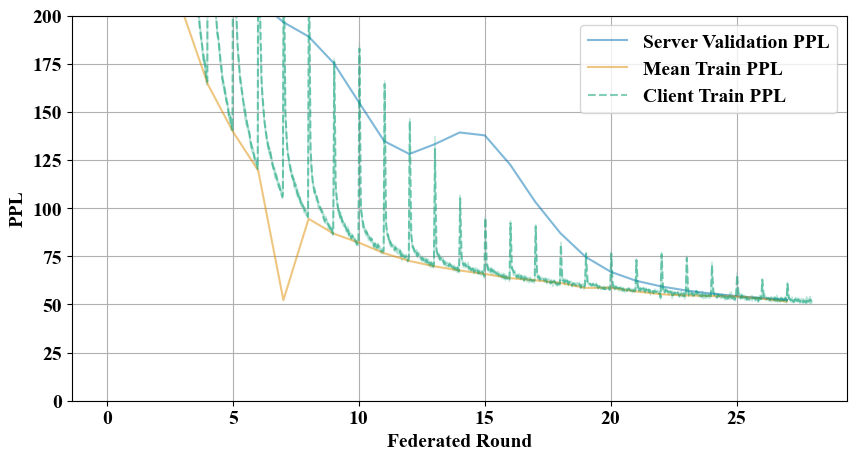

In [ ]:
plot_single_federated_run_ppl(server_data_frame, clients_data_frame)

In [ ]:
def plot_single_federated_run_l2_model(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_model",
        label="Global Model L2 Norm",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_fedavg_result",
        label="Global Model L2 Norm - FedAvg",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[0],
    )
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/param/global",
        label="Client Model L2 Norm",
        alpha=0.5,
        color=color_palette[3],
        linestyle=line_styles[1],
    )
    plt.grid()
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("Model L2 Norm")
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

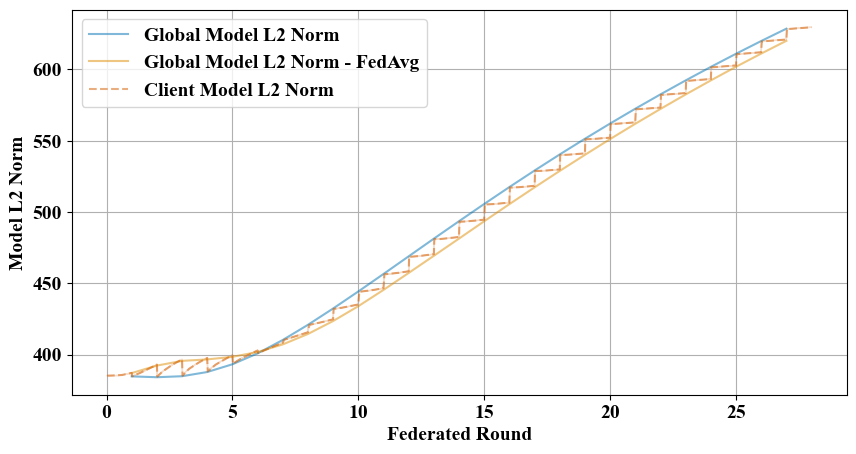

In [ ]:
plot_single_federated_run_l2_model(server_data_frame, clients_data_frame)

In [ ]:
def plot_single_federated_run_l2_global_momentum(
    server_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    patches = []
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_momentum_vector",
        label="Global Momentum",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[0],
            linestyle=line_styles[0],
            label="Global Momentum",
        )
    )
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_model",
        label="Global Model",
        alpha=0.5,
        color=color_palette[1],
        linestyle=line_styles[0],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[1],
            linestyle=line_styles[0],
            label="Global Model",
        )
    )
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("L2 Norm")
    plt.grid()
    # Add the legend manually
    plt.legend(loc="right", handles=patches)
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

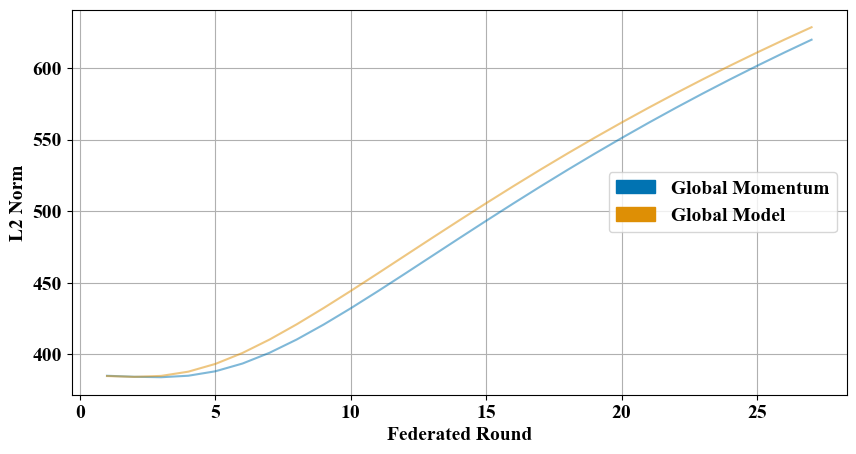

In [ ]:
plot_single_federated_run_l2_global_momentum(server_data_frame)

In [ ]:
def plot_single_federated_run_l2_gradient(
    server_data_frame: pd.DataFrame,
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Sort `server_data_frame` by `_step`
    tmp_server_data_frame = server_data_frame.sort_values(by="_step")
    # Reset the index of `server_data_frame`
    tmp_server_data_frame = tmp_server_data_frame.reset_index(drop=True)
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    patches = []
    sns.lineplot(
        data=tmp_server_data_frame,
        x="_step",
        y="server/l2_norm_pseudo_gradient",
        label="FedAvg Pseudo-Gradient",
        alpha=0.5,
        color=color_palette[0],
        linestyle=line_styles[0],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[0],
            linestyle=line_styles[0],
            label="FedAvg Pseudo-Gradient",
        )
    )
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    # Add a new y-axis for the next plot
    plt.ylabel("Server L2 Norm")
    plt.xlabel("Federated Round")
    plt.grid()
    plt.legend().remove()
    ax2 = plt.twinx()
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/grad/global",
        label="Client Computed Step-Gradient",
        alpha=0.5,
        ax=ax2,
        color=color_palette[1],
        linestyle=line_styles[1],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[1],
            linestyle=line_styles[1],
            label="Client Computed Step-Gradient",
        )
    )
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="l2_norm/update/global",
        label="Client Applied Step-Gradient",
        alpha=0.5,
        ax=ax2,
        color=color_palette[2],
        linestyle=line_styles[1],
    )
    patches.append(
        mpatches.Patch(
            color=color_palette[2],
            linestyle=line_styles[1],
            label="Client Applied Step-Gradient",
        )
    )
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("Client L2 Norm")
    # Add the legend manually
    plt.legend(loc="right", handles=patches)
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

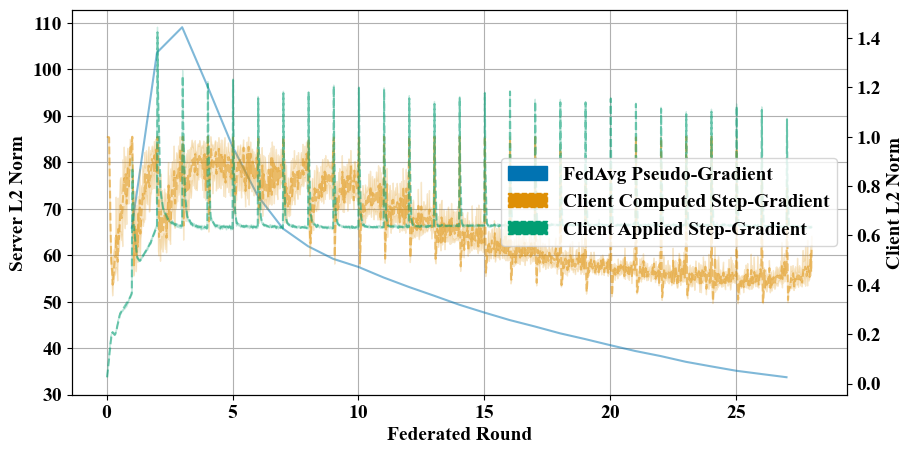

In [ ]:
plot_single_federated_run_l2_gradient(server_data_frame, clients_data_frame)

In [ ]:
def plot_single_federated_run_lr(
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    # Add a new y-axis for the next plot
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="lr-DecoupledAdamW/group0",
        alpha=0.5,
        color=color_palette[2],
        linestyle=line_styles[1],
    )
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("Client Learning Rate")
    plt.grid()
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

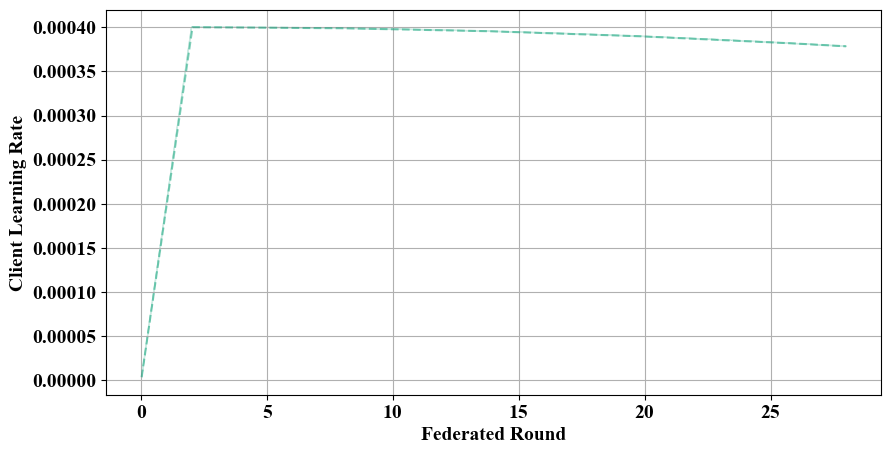

In [ ]:
plot_single_federated_run_lr(clients_data_frame)

In [ ]:
def plot_single_federated_run_output_activation(
    clients_data_frame: pd.DataFrame,
    file_name: str | None = None,
) -> None:
    """Plot the metrics from a single federated run."""
    # Plot nicely using matplotlib `ValLanguagePerplexity` versus `_step` from server data
    # frame dropping NaN values
    plt.figure(figsize=(10, 5))
    # Sort `clients_data_frame` by `_step`
    tmp_clients_data_frame = clients_data_frame.sort_values(by="_step")
    # Reset the index of `clients_data_frame`
    tmp_clients_data_frame = tmp_clients_data_frame.reset_index(drop=True)
    # Keep only steps that are multiples of 10
    tmp_clients_data_frame = tmp_clients_data_frame[
        tmp_clients_data_frame["_step"] % 10 == 0
    ]
    # Divide the number the column `_step` by 500
    tmp_clients_data_frame["_step"] = tmp_clients_data_frame["_step"] / 500
    # Add a new y-axis for the next plot
    sns.lineplot(
        data=tmp_clients_data_frame,
        x="_step",
        y="activations/l2_norm/full_model_output",
        alpha=0.5,
        color=color_palette[3],
        label="Client Output Activations",
        linestyle=line_styles[1],
    )
    # Set x and y labels
    plt.xlabel("Federated Round")
    plt.ylabel("L2 Norm")
    plt.grid()
    # plt.legend()
    # Save the figure
    if file_name:
        plt.savefig(file_name, format="pdf", dpi=800, bbox_inches="tight")
    # Show the figure
    plt.show()

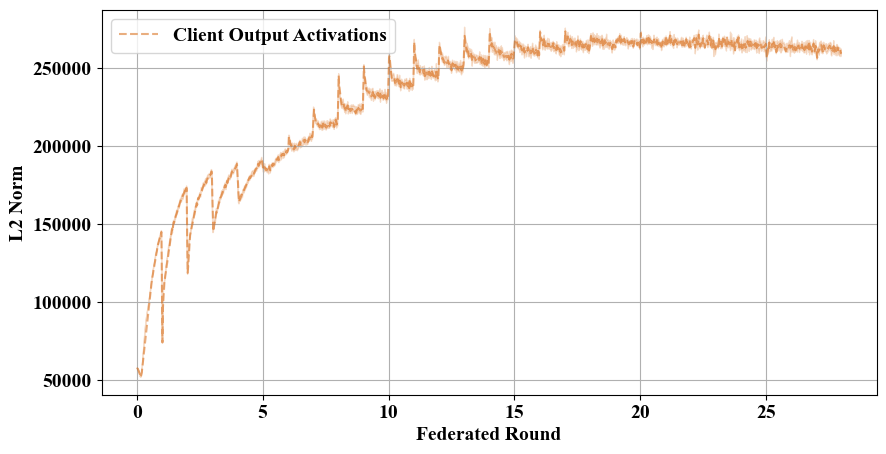

In [ ]:
plot_single_federated_run_output_activation(clients_data_frame)

In [ ]:
# TODO: PPLs comparing federated against centralised in the same plot (3+2 lines)
# TODO: Model L2 Norm comparing federated against centralised in the same plot (3+1 lines)
# TODO: Activations L2 Norm comparing federated against centralised in the same plot (1+1 lines, at most 2+2 lines)

In [198]:
server_df_list: list[pd.DataFrame] = []
clients_df_list: list[pd.DataFrame] = []
for record in run_id_dict["fed-350M"]:
    data_frames = download_metrics(record[0], record[1], drop_layers=False)
    server_data_frame, clients_data_frame = data_frames[0], data_frames[1]
    server_df_list.append(server_data_frame)
    clients_df_list.append(clients_data_frame)
server_data_frame = pd.concat(server_df_list).dropna()
clients_data_frame = pd.concat(clients_df_list).dropna()

In [209]:
server_data_frame

,server/layer/2/l2_norm_pseudo_gradient,server/layer/31/l2_norm_fedavg_result,client/layer/71/l2_norm_of_pseudo_gradient,node_training_time_s,server/layer/168/l2_norm_fedavg_result,server/layer/26/l2_norm_pseudo_gradient,server/layer/113/l2_norm_momentum_vector,server/layer/117/l2_norm_model,server/layer/76/l2_norm_fedavg_result,server/layer/117/l2_norm_momentum_vector,...,server/layer/198/l2_norm_momentum_vector,server/layer/13/l2_norm_model,server/layer/82/l2_norm_model,server/layer/40/l2_norm_momentum_vector,client/layer/203/l2_norm_of_pseudo_gradient,client/layer/158/l2_norm_of_pseudo_gradient,server/layer/178/l2_norm_pseudo_gradient,step,client/fit_set_parameters_time,client/eval_set_parameters_time
0,0.104010,90.971896,0.184830,3089.704496,0.073911,0.036560,6.579955,31.990916,0.041078,31.995218,...,0.025723,78.359866,0.022232,0.003860,0.089610,0.044660,0.075561,0,0.299912,0.608421
1,0.119428,91.227438,0.275242,3103.714220,0.100668,0.069990,6.890700,31.985561,0.070853,31.990132,...,0.074017,78.358202,0.057113,0.011948,0.123339,0.065329,0.104585,1,0.225256,0.594378
2,0.087714,91.500924,0.382369,3102.080640,0.102581,0.055217,7.696816,31.965647,0.062896,31.977240,...,0.136651,78.339427,0.105351,0.021903,0.117170,0.053397,0.109233,2,0.223553,0.606017
3,0.077895,91.695500,0.337991,3104.389398,0.111641,0.055804,9.054835,31.934837,0.060578,31.954914,...,0.204779,78.300929,0.165557,0.030684,0.142462,0.052317,0.091105,3,0.220576,0.607163
4,0.078995,91.936551,0.253868,3093.628956,0.122561,0.047127,10.882648,31.889161,0.060875,31.920296,...,0.274446,78.251051,0.227799,0.040139,0.150100,0.034638,0.087605,4,0.213567,0.606266
5,0.069817,92.315450,0.215348,3111.886076,0.136363,0.034320,13.033932,31.824956,0.064139,31.870104,...,0.342378,78.191896,0.286655,0.050682,0.146140,0.032410,0.071030,5,0.222695,0.612550
6,0.058864,92.750383,0.184172,3106.303481,0.148492,0.032819,15.396700,31.742167,0.074397,31.802753,...,0.406876,78.134626,0.341011,0.062213,0.112890,0.031135,0.060098,6,0.217456,0.599767
7,0.051429,93.315412,0.167607,3096.784790,0.165724,0.028373,17.887511,31.640232,0.080618,31.717197,...,0.466308,78.083233,0.388165,0.074086,0.090655,0.030574,0.055638,7,0.224864,0.578213
8,0.045680,93.696186,0.165122,3116.079950,0.181310,0.027563,20.445092,31.522705,0.091732,31.614812,...,0.519458,78.042806,0.429176,0.086160,0.086100,0.028864,0.055136,8,0.229135,0.744281
9,0.038230,94.232752,0.157145,3102.976693,0.200015,0.027613,23.015337,31.391621,0.101250,31.497321,...,0.565860,78.014531,0.462977,0.097980,0.087102,0.028306,0.053663,9,0.220672,0.616622


In [239]:
def plot_block_wise_heatmap(
    server_data_frame: pd.DataFrame,
    layer_wise_metric: str = "/l2_norm_pseudo_gradient",
    block_size=12,
    cmap="coolwarm",
    normalize=False,
) -> None:
    """Plot a heatmap with the round as the x-axis and the layer index as the y-axis.
    Layers are processed in blocks of block_size starting from the end
    """
    layer_df = server_data_frame.filter(like=layer_wise_metric)
    stripped_columns = layer_df.rename(
        columns=lambda x: x.replace(layer_wise_metric, "")
    )
    stripped_columns = stripped_columns.rename(
        columns=lambda x: x.replace("server/layer/", "")
    )
    stripped_columns = stripped_columns.drop(columns=["server", "client"])
    print(stripped_columns.columns)
    new_columns = {
        col: pd.to_numeric(col, errors="coerce") for col in stripped_columns.columns
    }
    numeric_columns = stripped_columns.rename(columns=new_columns)
    sorted_columns = numeric_columns.sort_index(axis=1, ascending=True)
    print(sorted_columns)
    transposed_dataframe = sorted_columns.T

    if normalize:
        transposed_dataframe = transposed_dataframe.apply(
            lambda x: (x - x.min()) / (x.max() - x.min()), axis=1
        )

    for i in range(len(transposed_dataframe) - 1, -1, -block_size):
        # Select the columns for this heatmap
        start = max(0, i - block_size + 1)
        end = i + 1
        subset = transposed_dataframe.iloc[start:end]

        # Create the heatmap
        sns.heatmap(subset, cmap=cmap)
        plt.title(f"Heatmap for layers {start} to {end}")
        plt.xlabel("Round")
        plt.ylabel("Layer Index")
        plt.savefig(f"heatmap_{i}")
        plt.close()